In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
using LinearAlgebra
import ForwardDiff as FD
import MeshCat as mc
using Test

using LaTeXStrings
using Plots
pyplot()
PyPlot.matplotlib.rc("text", usetex = true)
PyPlot.matplotlib.rc("font", family = "Times New Roman")
PyPlot.matplotlib.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

using JupyterFormatter
enable_autoformat();

  Activating project at `~/optimal-control/code/hw1/Q2`


# Q2: Equality Constrained Optimization
In this problem, we are going to use Newton's method to solve some constrained optimization problems. We will start with a smaller problem where we can experiment with Full Newton vs Gauss-Newton, then we will use these methods to solve for the motor torques that make a quadruped balance on one leg.

## Part A (10 pts)
Here we are going to solve some equality-constrained optimization problems with Newton's method. We are given a problem 

$$ \begin{align} \min_x \quad & f(x) \\ 
 \mbox{st} \quad & c(x) = 0 
 \end{align}$$
 
Which has the following KKT conditions for optimality:
$$\begin{align}
\nabla_x f(x) + \bigg[ \frac{\partial c}{\partial x}\bigg] ^T \lambda &= 0 \\ 
c(x) &= 0 
\end{align}$$

Which is just a root-finding problem. To solve this, we are going to solve for a $z = [x^T,\lambda]^T$ that satisfies these KKT conditions.

### Newton's Method with a Linesearch

We use Newton's method to solve for when $r(z) = 0$. To do this, we specify `res_fx(z)` as $r(z)$, and `res_jac_fx(z)` as $\partial r/ \partial z$. To calculate a Newton step, we do the following:

$$\Delta z = -\bigg[ \frac{\partial r}{\partial z} \bigg]^{-1} r(z_k)$$

We then decide the step length with a linesearch that finds the largest $\alpha \leq 1$ such that the following is true:
$$ \phi(z_k + \alpha \Delta z) < \phi(z_k)$$
Where $\phi$ is a "merit function", or `merit_fx(z)` in the code. In this assignment you will use a backtracking linesearch where $\alpha$ is initialized as $\alpha = 1.0$, and is divided by 2 until the above condition is satisfied.

NOTE: YOU DO NOT NEED TO (AND SHOULD NOT) USE A WHILE LOOP ANYWHERE IN THIS ASSIGNMENT. 

In [2]:
function linesearch(z::Vector, Δz::Vector, merit_fx::Function; max_ls_iters = 10)::Float64 # optional argument with a default

    # return maximum α≤1 such that merit_fx(z + α*Δz) < merit_fx(z)
    # with a backtracking linesearch (α = α/2 after each iteration)
    ϕ0 = merit_fx(z)
    α = 1.0
    for i = 1:max_ls_iters
        if merit_fx(z + α * Δz) < ϕ0
            return α
        else
            α = α / 2
        end
    end
    error("linesearch failed")
end

function newtons_method(
    z0::Vector,
    res_fx::Function,
    res_jac_fx::Function,
    merit_fx::Function;
    tol = 1e-10,
    max_iters = 50,
    verbose = false,
)::Vector{Vector{Float64}}

    # implement Newton's method given the following inputs:
    # - z0, initial guess 
    # - res_fx, residual function 
    # - res_jac_fx, Jacobian of residual function wrt z 
    # - merit_fx, merit function for use in linesearch 

    # return a vector of vectors containing the iterates 
    # the last vector in this vector of vectors should be the approx. solution 

    # return the history of guesses as a vector
    Z = [zeros(length(z0)) for i = 1:max_iters]
    Z[1] = z0

    for i = 1:(max_iters-1)

        # evaluate current residual 
        r = res_fx(Z[i])
        norm_r = norm(r)
        if verbose
            print("iter: $i    |r|: $norm_r   ")
        end

        # check convergence with norm of residual < tol 
        if norm_r < tol
            return Z[1:i]
        end

        # caculate Newton step (don't forget the negative sign)
        J = res_jac_fx(Z[i])
        Δz = -J \ r

        # linesearch and update z 
        α = linesearch(Z[i], Δz, merit_fx)
        Z[i+1] = Z[i] + α * Δz
        if verbose
            print("α: $α \n")
        end

    end
    error("Newton's method did not converge")
end

newtons_method (generic function with 1 method)

In [3]:
@testset "check Newton" begin

    f(_x) = [sin(_x[1]), cos(_x[2])]
    df(_x) = FD.jacobian(f, _x)
    merit(_x) = norm(f(_x))

    x0 = [-1.742410372590328, 1.4020334125022704]

    X = newtons_method(x0, f, df, merit; tol = 1e-10, max_iters = 50, verbose = true)

    # check this took the correct number of iterations
    # if your linesearch isn't working, this will fail 
    # you should see 1 iteration where α = 0.5 
    @test length(X) == 6

    # check we actually converged
    @test norm(f(X[end])) < 1e-10

end

iter: 1    |r|: 0.9995239729818045   α: 1.0 
iter: 2    |r|: 0.9421342427117169   α: 0.5 
iter: 3    |r|: 0.1753172908866053   α: 1.0 
iter: 4    |r|: 0.0018472215879181287   α: 1.0 
iter: 5    |r|: 2.1010529101114843e-9   α: 1.0 
iter: 6    |r|: 2.5246740534795566e-16   Test Summary: | Pass  Total  Time
check Newton  |    2      2  1.0s


Test.DefaultTestSet("check Newton", Any[], 2, false, false, true, 1.692452233538293e9, 1.692452234491054e9, false)

We will now use Newton's method to solve the following constrained optimization problem. We will write functions for the full Newton Jacobian, as well as the Gauss-Newton Jacobian. 

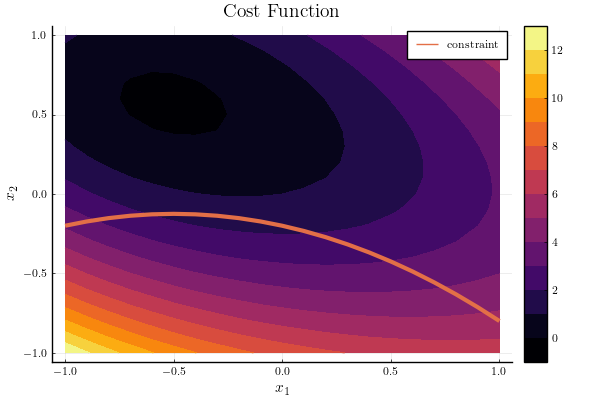

sys:1: UserWarning: The following kwargs were not used by contour: 'label'
sys:1: UserWarning: The following kwargs were not used by contour: 'label'


In [4]:
let
    Q = [1.65539 2.89376; 2.89376 6.51521]
    q = [2; -3]
    cost(x) = 0.5 * x' * Q * x + q' * x + exp(-1.3 * x[1] + 0.3 * x[2]^2) # cost function 
    contour(
        -1:0.1:1,
        -1:0.1:1,
        (x1, x2) -> cost([x1; x2]),
        title = "Cost Function",
        xlabel = L"x_1",
        ylabel = L"x_2",
        fill = true,
    )
    plot!(
        -1:0.1:1,
        -0.3 * (-1:0.1:1) .^ 2 - 0.3 * (-1:0.1:1) .- 0.2,
        lw = 3,
        label = "constraint",
    )
end

In [5]:
# we will use Newton's method to solve the constrained optimization problem shown above

# HINT 
function constraint_jacobian(x)
    # since `constraint` returns a scalar value, ForwardDiff 
    # will only allow us to compute a gradient of this function 
    # (instead of a Jacobian). This means we have two options for
    # computing the Jacobian: Option 1 is to just reshape the gradient
    # into a row vector

    # J = reshape(FD.gradient(constraint, x), 1, 2)

    # or we can just make the output of constraint an array, 
    constraint_array(_x) = [constraint(_x)]
    J = FD.jacobian(constraint_array, x)

    # assert the jacobian has # rows = # outputs 
    # and # columns = # inputs 
    @assert size(J, 1) == length(constraint(x))
    @assert size(J, 2) == length(x)

    return J
end
function cost(x)
    Q = [1.65539 2.89376; 2.89376 6.51521]
    q = [2; -3]
    return 0.5 * x' * Q * x + q' * x + exp(-1.3 * x[1] + 0.3 * x[2]^2)
end
function constraint(x)
    norm(x) - 0.5
end
function kkt_conditions(z)
    # TODO: return the KKT conditions

    x = z[1:2]
    λ = z[3:3]

    # TODO: return the stationarity condition for the cost function
    # and the primal feasibility

    A = constraint_jacobian(x)
    [
        FD.gradient(cost, x) + A' * λ
        constraint(x)
    ]
end

function fn_kkt_jac(z)
    # TODO: return full Newton Jacobian of kkt conditions wrt z
    x = z[1:2]
    λ = z[3]

    # TODO: return full Newton jacobian with a 1e-3 regularizer
    _lag(_x) = cost(_x) + λ * constraint(_x)
    A = FD.gradient(constraint, x)'
    H = FD.hessian(_lag, x)
    ρ = 1e-3
    return [H+ρ*I A'; A -ρ*I]
end
function gn_kkt_jac(z)
    # TODO: return Gauss-Newton Jacobian of kkt conditions wrt z 
    x = z[1:2]
    λ = z[3]

    # TODO: return Gauss-Newton jacobian with a 1e-3 regularizer
    A = FD.gradient(constraint, x)'
    H = FD.hessian(cost, x)
    ρ = 1e-3
    return [H+ρ*I A'; A -ρ*I]
end

gn_kkt_jac (generic function with 1 method)

In [6]:
@testset "Test Jacobians" begin

    # first we check the regularizer 
    z = randn(3)
    J_fn = fn_kkt_jac(z)
    J_gn = gn_kkt_jac(z)

    # check what should/shouldn't be the same between 
    @test norm(J_fn[1:2, 1:2] - J_gn[1:2, 1:2]) > 1e-10
    @test abs(J_fn[3, 3] + 1e-3) < 1e-10
    @test abs(J_gn[3, 3] + 1e-3) < 1e-10
    @test norm(J_fn[1:2, 3] - J_gn[1:2, 3]) < 1e-10
    @test norm(J_fn[3, 1:2] - J_gn[3, 1:2]) < 1e-10
end

Test Summary:  | Pass  Total  Time
Test Jacobians |    5      5  2.3s


Test.DefaultTestSet("Test Jacobians", Any[], 5, false, false, true, 1.692452245467244e9, 1.692452247781208e9, false)

iter: 1    |r|: 1.7188450769812715   α: 1.0 
iter: 2    |r|: 0.815049596220325   α: 1.0 
iter: 3    |r|: 0.025448943695826724   α: 1.0 
iter: 4    |r|: 9.501514353541471e-5   

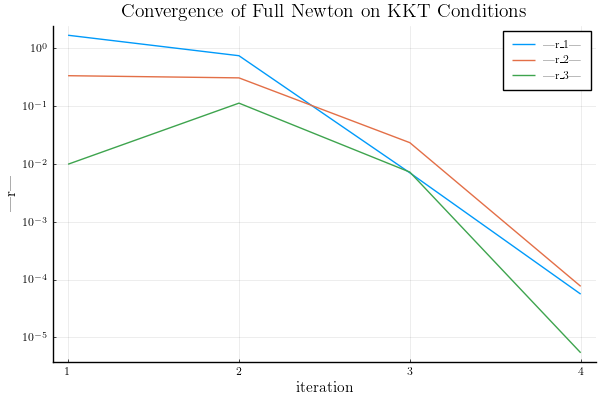

Test Summary: | Pass  Total  Time
Full Newton   |    2      2  3.4s


sys:1: UserWarning: The following kwargs were not used by contour: 'label'
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: The following kwargs were not used by contour: 'label'
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: The following kwargs were not used by contour: 'label'
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


PyPlot.Figure(PyObject <Figure size 600x400 with 2 Axes>)

Test.DefaultTestSet("Full Newton", Any[], 2, false, false, true, 1.692452247794738e9, 1.692452251155553e9, false)

In [7]:
@testset "Full Newton" begin


    z0 = [-.1, 0.5, 0] # initial guess
    merit_fx(_z) = norm(kkt_conditions(_z)) # simple merit function
    Z = newtons_method(
        z0,
        kkt_conditions,
        fn_kkt_jac,
        merit_fx;
        tol = 1e-4,
        max_iters = 100,
        verbose = true,
    )
    R = kkt_conditions.(Z)

    # make sure we converged on a solution to the KKT conditions 
    @test norm(kkt_conditions(Z[end])) < 1e-4
    @test length(R) < 6


    # plotting stuff
    Rp = [[abs(R[i][ii]) + 1e-15 for i = 1:length(R)] for ii = 1:length(R[1])] # this gets abs of each term at each iteration

    plot(
        Rp[1],
        yaxis = :log,
        ylabel = "|r|",
        xlabel = "iteration",
        yticks = [1.0 * 10.0^(-x) for x in float(15:-1:-2)],
        title = "Convergence of Full Newton on KKT Conditions",
        label = "|r_1|",
    )
    plot!(Rp[2], label = "|r_2|")
    display(plot!(Rp[3], label = "|r_3|"))

    contour(
        -.6:0.1:0,
        0:0.1:0.6,
        (x1, x2) -> cost([x1; x2]),
        title = "Cost Function",
        xlabel = "X₁",
        ylabel = "X₂",
        fill = true,
    )
    xcirc = [0.5 * cos(θ) for θ in range(0, 2 * pi, length = 200)]
    ycirc = [0.5 * sin(θ) for θ in range(0, 2 * pi, length = 200)]
    plot!(xcirc, ycirc, lw = 3.0, xlim = (-.6, 0), ylim = (0, 0.6), label = "constraint")
    z1_hist = [z[1] for z in Z]
    z2_hist = [z[2] for z in Z]
    display(plot!(z1_hist, z2_hist, marker = :d, label = "xₖ"))

end

iter: 1    |r|: 1.7188450769812715   α: 1.0 
iter: 2    |r|: 0.815049596220325   α: 1.0 
iter: 3    |r|: 0.19186516708148585   α: 1.0 
iter: 4    |r|: 0.04663490553083133   α: 1.0 
iter: 5    |r|: 0.013329778429546028   α: 1.0 
iter: 6    |r|: 0.0037714013578573355   α: 1.0 
iter: 7    |r|: 0.001071165054782875   α: 1.0 
iter: 8    |r|: 0.00030392210707413806   α: 1.0 
iter: 9    |r|: 8.625764141582568e-5   

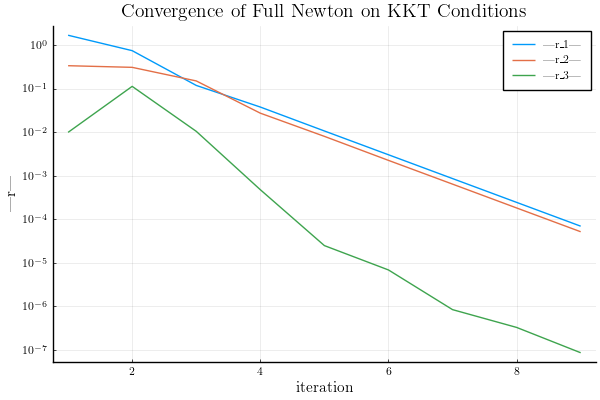

Test Summary: | Pass  Total  Time
Gauss-Newton  |    2      2  1.1s


sys:1: UserWarning: The following kwargs were not used by contour: 'label'
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: The following kwargs were not used by contour: 'label'
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: The following kwargs were not used by contour: 'label'
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


PyPlot.Figure(PyObject <Figure size 600x400 with 2 Axes>)

Test.DefaultTestSet("Gauss-Newton", Any[], 2, false, false, true, 1.692452251442184e9, 1.692452252525569e9, false)

In [8]:
@testset "Gauss-Newton" begin


    z0 = [-.1, 0.5, 0] # initial guess
    merit_fx(_z) = norm(kkt_conditions(_z)) # simple merit function

    # the only difference in this block vs the previous is `gn_kkt_jac` instead of `fn_kkt_jac`
    Z = newtons_method(
        z0,
        kkt_conditions,
        gn_kkt_jac,
        merit_fx;
        tol = 1e-4,
        max_iters = 100,
        verbose = true,
    )
    R = kkt_conditions.(Z)

    # make sure we converged on a solution to the KKT conditions 
    @test norm(kkt_conditions(Z[end])) < 1e-4
    @test length(R) < 10


    # plotting stuff
    Rp = [[abs(R[i][ii]) + 1e-15 for i = 1:length(R)] for ii = 1:length(R[1])] # this gets abs of each term at each iteration

    plot(
        Rp[1],
        yaxis = :log,
        ylabel = "|r|",
        xlabel = "iteration",
        yticks = [1.0 * 10.0^(-x) for x in float(15:-1:-2)],
        title = "Convergence of Full Newton on KKT Conditions",
        label = "|r_1|",
    )
    plot!(Rp[2], label = "|r_2|")
    display(plot!(Rp[3], label = "|r_3|"))

    contour(
        -.6:0.1:0,
        0:0.1:0.6,
        (x1, x2) -> cost([x1; x2]),
        title = "Cost Function",
        xlabel = "X₁",
        ylabel = "X₂",
        fill = true,
    )
    xcirc = [0.5 * cos(θ) for θ in range(0, 2 * pi, length = 200)]
    ycirc = [0.5 * sin(θ) for θ in range(0, 2 * pi, length = 200)]
    plot!(xcirc, ycirc, lw = 3.0, xlim = (-.6, 0), ylim = (0, 0.6), label = "constraint")
    z1_hist = [z[1] for z in Z]
    z2_hist = [z[2] for z in Z]
    display(plot!(z1_hist, z2_hist, marker = :d, label = "xₖ"))

end

## Part B (10 pts): Balance a quadruped
Now we are going to solve for the control input $u \in \mathbb{R}^{12}$, and state $x \in \mathbb{R}^{30}$, such that the quadruped is balancing up on one leg. First, let's load in a model and display the rough "guess" configuration that we are going for:

In [16]:
Pkg.add("Rotations")

   Resolving package versions...
    Updating `~/optimal-control/code/hw1/Q2/Project.toml`
  [6038ab10] + Rotations v1.5.1
  No Changes to `~/optimal-control/code/hw1/Q2/Manifest.toml`


In [17]:
include(joinpath(@__DIR__, "quadruped.jl"))

# --------these three are global variables------------
model = UnitreeA1()
mvis = initialize_visualizer(model)
const x_guess = initial_state(model)
# ----------------------------------------------------

set_configuration!(mvis, x_guess[1:state_dim(model)÷2])
render(mvis)

[ Info: Listening on: 127.0.0.1:8700, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8700


MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("meshcat" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("world" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("dummy1" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x72, 0x6c, 0x64, 0x2f, 0x64, 0x75, 0x6d, 0x6d, 0x79, 0x31], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("dummy2" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x6d, 0x79, 0x31, 0x2f, 0x64, 0x75, 0x6d, 0x6d, 0x79, 0x32], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("RR_foot" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x79, 0x32, 0x2f, 0x52, 0x52, 0x5f, 0x66, 0x6f, 0x6f, 0x74], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("after_RR_foot_fixed" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x66, 0x6f, 0x6f, 0x74, 0x5f, 0x66, 0x69, 0x78, 0x65, 0x64], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("geometry_15" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x35], UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x35], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))), "RR_calf" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x6f, 0x74, 0x2f, 0x52, 0x52, 0x5f, 0x63, 0x61, 0x6c, 0x66], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("after_RR_calf_joint" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x63, 0x61, 0x6c, 0x66, 0x5f, 0x6a, 0x6f, 0x69, 0x6e, 0x74], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("geometry_14" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x34], UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x34], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))), "RR_thigh" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x66, 0x2f, 0x52, 0x52, 0x5f, 0x74, 0x68, 0x69, 0x67, 0x68], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("after_RR_thigh_joint" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x68, 0x69, 0x67, 0x68, 0x5f, 0x6a, 0x6f, 0x69, 0x6e, 0x74], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("geometry_13" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x33], UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x33], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))), "RR_hip" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x69, 0x67, 0x68, 0x2f, 0x52, 0x52, 0x5f, 0x68, 0x69, 0x70], Dict{String, Vector{UI

Now, we are going to solve for the state and control that get us a statically stable stance on just one leg. We are going to do this by solving the following optimization problem:

$$ \begin{align} \min_{x,u} \quad & \frac{1}{2}(x - x_{guess})^T(x - x_{guess}) + \frac{1}{2}10^{-3} u^Tu \\ 
 \mbox{st} \quad & f(x,u) = 0 
 \end{align}$$
 
 Where our primal variables are $x \in \mathbb{R}^{30}$ and $u \in \mathbb{R}^{12}$, that we can stack up in a new variable $y = [x^T, u^T]^T \in \mathbb{R}^{42}$. We have a constraint $f(x,u) = \dot{x} = 0$, which will ensure the resulting configuration is stable. This constraint is enforced with a dual variable $\lambda \in \mathbb{R}^{30}$. We are now ready to use Newton's method to solve this equality constrained optimization problem, where we will solve for a variable $z = [y^T, \lambda^T]^T \in \mathbb{R}^{72}$.
 
 In this next section, you should fill out `quadruped_kkt(z)` with the KKT conditions for this optimization problem, given the constraint is that `dynamics(model, x, u) = zeros(30)`. When forming the Jacobian of the KKT conditions, use the Gauss-Newton approximation for the hessian of the Lagrangian (see example above if you're having trouble with this).

In [18]:
# initial guess 
const x_guess = initial_state(model)

# indexing stuff 
const idx_x = 1:30
const idx_u = 31:42
const idx_c = 43:72

# I like stacking up all the primal variables in y, where y = [x;u]
# Newton's method will solve for z = [x;u;λ], or z = [y;λ]

function quadruped_cost(y)
    # cost function 
    @assert length(y) == 42
    x = y[idx_x]
    u = y[idx_u]

    # TODO: return cost 
    return 0.5 * norm(x - x_guess)^2 + 0.5 * 1e-3 * norm(u)^2
end
function quadruped_constraint(y)
    # constraint function 
    @assert length(y) == 42
    x = y[idx_x]
    u = y[idx_u]

    # TODO: return constraint
    return dynamics(model, x, u)
end
function quadruped_kkt(z)
    @assert length(z) == 72
    x = z[idx_x]
    u = z[idx_u]
    λ = z[idx_c]

    y = [x; u]

    # TODO: return the KKT conditions 
    [
        FD.gradient(quadruped_cost, y) + FD.jacobian(quadruped_constraint, y)' * λ
        quadruped_constraint(y)
    ]
end

function quadruped_kkt_jac(z)
    @assert length(z) == 72
    x = z[idx_x]
    u = z[idx_u]
    λ = z[idx_c]

    y = [x; u]

    # TODO: return Gauss-Newton Jacobian with 1e-4 regularizer 

    A = FD.jacobian(quadruped_constraint, y)
    H = FD.hessian(quadruped_cost, y)
    ρ = 1e-4
    [(H+ρ*I) A'; A -ρ*I]
end

quadruped_kkt_jac (generic function with 1 method)

iter: 1    |r|: 217.37236872332164   α: 1.0 
iter: 2    |r|: 89.0901933297234   α: 0.25 
iter: 3    |r|: 72.70509015406466   α: 0.25 
iter: 4    |r|: 68.78730314439419   α: 0.25 
iter: 5    |r|: 64.15825504286259   α: 0.25 
iter: 6    |r|: 55.89043490744272   α: 0.25 
iter: 7    |r|: 48.47794476249872   α: 0.25 
iter: 8    |r|: 41.99756158364312   α: 0.5 
iter: 9    |r|: 40.78057174842657   α: 1.0 
iter: 10    |r|: 27.169631092985192   α: 1.0 
iter: 11    |r|: 1.393353873506101   α: 1.0 
iter: 12    |r|: 0.5249209755832283   α: 1.0 
iter: 13    |r|: 143.73665245876825   α: 1.0 
iter: 14    |r|: 9.971414571460507   α: 1.0 
iter: 15    |r|: 0.5377490577235624   α: 1.0 
iter: 16    |r|: 0.07582705085810697   α: 1.0 
iter: 17    |r|: 0.026632693862239768   α: 1.0 
iter: 18    |r|: 0.0006245636426117161   α: 1.0 
iter: 19    |r|: 0.0002341661632647437   α: 1.0 
iter: 20    |r|: 2.3047734158191364e-5   α: 1.0 
iter: 21    |r|: 4.670932514552915e-6   α: 1.0 
iter: 22    |r|: 6.92260838269062e

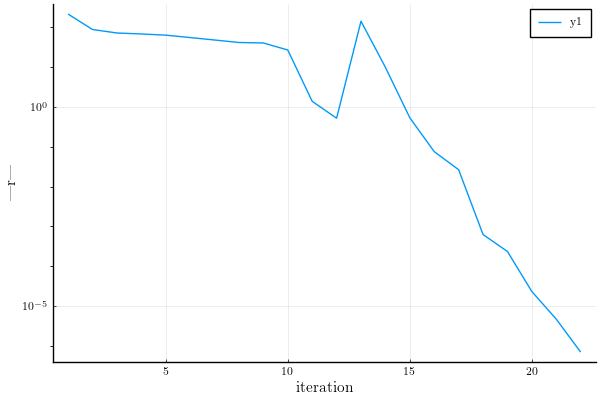

Test Summary:      | Pass  Total   Time
quadruped standing |    2      2  21.5s


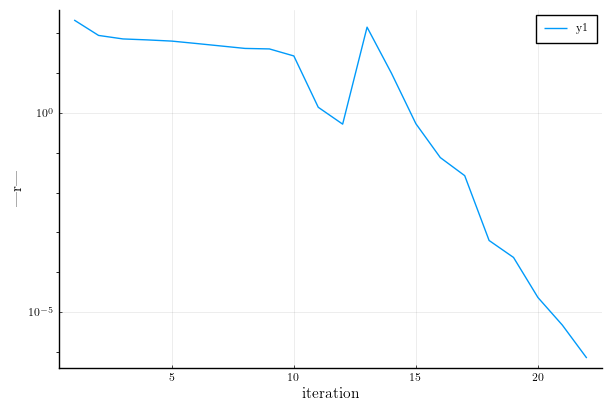

Test.DefaultTestSet("quadruped standing", Any[], 2, false, false, true, 1.692452530485692e9, 1.692452552031115e9, false)

In [19]:
function quadruped_merit(z)
    # merit function for the quadruped problem 
    @assert length(z) == 72
    r = quadruped_kkt(z)
    return norm(r[1:42]) + 1e4 * norm(r[43:end])
end

@testset "quadruped standing" begin

    z0 = [x_guess; zeros(12); zeros(30)]
    Z = newtons_method(
        z0,
        quadruped_kkt,
        quadruped_kkt_jac,
        quadruped_merit;
        tol = 1e-6,
        verbose = true,
        max_iters = 50,
    )
    set_configuration!(mvis, Z[end][1:state_dim(model)÷2])
    R = norm.(quadruped_kkt.(Z))

    display(plot(1:length(R), R, yaxis = :log, xlabel = "iteration", ylabel = "|r|"))

    @test R[end] < 1e-6

    x, u = Z[end][idx_x], Z[end][idx_u]

    @test norm(dynamics(model, x, u)) < 1e-6

end

In [20]:
let

    # let's visualize the balancing position we found

    z0 = [x_guess; zeros(12); zeros(30)]
    Z = newtons_method(
        z0,
        quadruped_kkt,
        quadruped_kkt_jac,
        quadruped_merit;
        tol = 1e-6,
        verbose = false,
        max_iters = 50,
    )
    # visualizer 
    mvis = initialize_visualizer(model)
    set_configuration!(mvis, Z[end][1:state_dim(model)÷2])
    render(mvis)


end

[ Info: Listening on: 127.0.0.1:8701, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8701


MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("meshcat" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("world" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("dummy1" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x72, 0x6c, 0x64, 0x2f, 0x64, 0x75, 0x6d, 0x6d, 0x79, 0x31], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("dummy2" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x6d, 0x79, 0x31, 0x2f, 0x64, 0x75, 0x6d, 0x6d, 0x79, 0x32], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("RR_foot" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x79, 0x32, 0x2f, 0x52, 0x52, 0x5f, 0x66, 0x6f, 0x6f, 0x74], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("after_RR_foot_fixed" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x66, 0x6f, 0x6f, 0x74, 0x5f, 0x66, 0x69, 0x78, 0x65, 0x64], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("geometry_15" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x35], UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x35], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))), "RR_calf" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x6f, 0x74, 0x2f, 0x52, 0x52, 0x5f, 0x63, 0x61, 0x6c, 0x66], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("after_RR_calf_joint" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x63, 0x61, 0x6c, 0x66, 0x5f, 0x6a, 0x6f, 0x69, 0x6e, 0x74], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("geometry_14" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x34], UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x34], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))), "RR_thigh" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x66, 0x2f, 0x52, 0x52, 0x5f, 0x74, 0x68, 0x69, 0x67, 0x68], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("after_RR_thigh_joint" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x68, 0x69, 0x67, 0x68, 0x5f, 0x6a, 0x6f, 0x69, 0x6e, 0x74], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("geometry_13" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x33], UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x65, 0x6f, 0x6d, 0x65, 0x74, 0x72, 0x79, 0x5f, 0x31, 0x33], Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))), "RR_hip" => MeshCat.SceneTrees.SceneNode(nothing, UInt8[0x83, 0xa6, 0x6d, 0x61, 0x74, 0x72, 0x69, 0x78, 0xc7, 0x40  …  0x69, 0x67, 0x68, 0x2f, 0x52, 0x52, 0x5f, 0x68, 0x69, 0x70], Dict{String, Vector{UI